# FAIR-TRACE / SCAFF — making the planted-sensitivity experiment robust

**What this notebook is.** The 2026-08-16 prototype reports that the stage crossover localizes a
planted attribute dependence with **100% accuracy**, and that repairing the implicated stage removes
the downstream disparity. Both claims are load-bearing for the paper, and neither survives contact
with the four defects found while reproducing them in
`0817_FAIR-TRACE_SCAFF_crossover_summary.ipynb`. This notebook fixes them and re-derives every
number the results section quotes.

| # | Defect | Fix | Section |
|---|---|---|---|
| ① | `top1_gap` as Rank's coordinate: repeat-noise floor (0.328) larger than the direct effect it estimates (0.094), and blind to true effects that don't move the top item | compare five graded rank distances on effect / floor / detection AUC — and first settle what actually contaminates $D^A$ | §2–§3 |
| ② | Repair removability scored on the repaired stage's own output is circular | score strictly downstream of the repair; report the full planted × repaired matrix | §5 |
| ③ | "100%" with no interval, from one seed | bootstrap + Wilson intervals; five-seed sweep | §4 |
| ④ | Detection margin $\tau = 0.10$ hand-set | calibrate from the control scenarios' own noise; sweep $\tau$ | §4 |

Plus one reporting distinction the write-up conflated: an Explain- or Memory-planted fault
**cannot** move a single-turn endpoint at all, because both stages sit downstream of the ranked
list. That is structural blindness, not low statistical power (§6).

**Scope.** The planted faults are unit tests of the measurement instrument. They are not estimates
of real-world disparity and assert nothing about the preferences or treatment of any group.

**Implementation.** No LangChain, no LLM, no API key: `numpy` + `pandas` only. Stages are transparent
functions over explicit parent-state dictionaries, so every $Z_s$ is addressable, holdable and
replayable, and it is provable by inspection that a stage saw the descriptor only through
`fires()`. That is a requirement of the crossover, not a shortcut.

## 1. Setup

Everything is computed by `scripts/scaff_robustness.py` and driven by
`scripts/run_scaff_robustness.py`, which writes `paper/scaff_robustness_results.json`. The notebook
calls that driver directly so there is exactly one set of numbers: what you read here is what the
`.tex` quotes. Re-running is byte-identical.

In [1]:
import json, pathlib, sys
import numpy as np, pandas as pd
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)

sys.path.insert(0, str(pathlib.Path.cwd() / "scripts"))
import scaff_robustness as R
import run_scaff_robustness as driver

RES = driver.main()          # ~90s; writes paper/scaff_robustness_results.json + the figure
frame = lambda key_path: pd.DataFrame(
    __import__("functools").reduce(lambda d, k: d[k], key_path.split("."), RES))

print(json.dumps(RES["config"], indent=2))

{
  "n_scenarios": 120,
  "n_per_stage": 20,
  "repeats": 8,
  "seeds": [
    42,
    43,
    44,
    45,
    46
  ],
  "catalog_size": 60,
  "rank_jitter": 0.1,
  "retrieve_temp": 0.06,
  "primary_rank_metric": "ndcg_delta",
  "legacy_margin": 0.1,
  "endpoint_margin": 0.02,
  "n_bootstrap": 4000
}


The substrate is the one-domain movie re-implementation of the 0817 notebook, extended with the
stochasticity the deterministic version lacked — without it there is no noise floor to study and
defect ① cannot be exhibited at all. It is tuned to sit in the shared run's regime rather than to
match it exactly (one domain, not two; a larger catalog): Retrieve repeat-noise 0.181 vs 0.166,
Rank direct effect 0.104 vs 0.094, Rank natural divergence 0.376 vs 0.396, all under the original
`top1_gap` coordinate.

In [2]:
frame("shared_eps.coordinates_legacy_metric").set_index("stage").reindex(R.STAGES)

,natural,direct,inherited,noise
stage,,,,
Elicit,0.0556,0.0556,0.0000,0.0000
Retrieve,0.2781,0.1394,0.1387,0.1810
Rank,0.3760,0.1042,0.2719,0.7708
Explain,0.1667,0.0833,0.0833,0.0000
Memory,0.1111,0.0556,0.0556,0.0000


## 2. The defect underneath defect ① — what actually contaminates $D^A$

Before swapping the metric, the more basic question: *why* would $D^A$ at Rank be noisy at all?

The formalism writes the crossover cell as

$$Y_s^{i,j} \;=\; \phi_s\!\left(f_s(Z_s^{i},\, A{=}j;\, \epsilon)\right)$$

— **one** $\epsilon$, shared by all four cells. That is not decoration. $D^A$ is a difference
between two cells; if each cell draws its own randomness, that difference is a mixture of the
effect and the sampling noise, and $D^A$ inherits the stage's entire noise floor. If $\epsilon$ is
held fixed, the noise cancels in the difference and $D^A$ is exact.

The prototype's reported numbers are consistent with the second, broken regime: a Rank noise
coordinate of 0.328 sitting next to a Rank direct effect of 0.094. Below, both regimes, same
trajectories, same metric.

In [3]:
comparison = (frame("shared_eps.coordinates_legacy_metric").set_index("stage")
              .join(frame("independent_eps.coordinates_legacy_metric").set_index("stage"),
                    lsuffix="_shared", rsuffix="_indep")
              .reindex(R.STAGES))
comparison[["natural_shared", "natural_indep", "direct_shared", "direct_indep",
            "inherited_shared", "inherited_indep"]]

,natural_shared,natural_indep,direct_shared,direct_indep,inherited_shared,inherited_indep
stage,,,,,,
Elicit,0.0556,0.0556,0.0556,0.0556,0.0000,0.0000
Retrieve,0.2781,0.3843,0.1394,0.2504,0.1387,0.2979
Rank,0.3760,0.8500,0.1042,0.7620,0.2719,0.7880
Explain,0.1667,0.1667,0.0833,0.0833,0.0833,0.0833
Memory,0.1111,0.1111,0.0556,0.0556,0.0556,0.0556


With independent $\epsilon$ the Rank row collapses: natural, direct and inherited all land within a
few points of each other and of the noise floor, so the decomposition carries no information at
that stage. With shared $\epsilon$ the same trajectories give a direct effect cleanly separated
from an inherited one.

**This is the single highest-leverage fix in the notebook, and it is free.** It also sets a hard
requirement for the real-data settings: either the agent's sampling is seed-controllable, or the
crossover has to be estimated against a coordinate robust to resampling — which is what §3 is for.

## 3. Defect ① — choosing Rank's coordinate

Five candidates, scored on the same trajectories:

- `top1_gap` — the prototype's choice; 0/1
- `top3_jaccard` — set overlap of the top 3
- `rbo_p90` — rank-biased overlap, $p=0.9$; graded and top-weighted
- `kendall_tau` — normalized Kendall tau distance over the union
- `ndcg_delta` — $|\mathrm{NDCG}(x) - \mathrm{NDCG}(y)|$ against the latent profile

The last one needs an oracle and the others don't — a real cost, and the reason it cannot simply be
mandated for settings without ground truth.

`effect` is the mean $D^A$ at Rank on Rank-planted scenarios; `floor` is the residual $D^A$ where
nothing was planted — the quantity a threshold must clear. `repeat_noise` is the within-condition
distance between repeats: it bounds how finely $D^{\mathrm{nat}}$ can be read, but does **not** by
itself contaminate $D^A$ once $\epsilon$ is shared. Conflating the two is what made the original
diagnosis of this defect imprecise.

In [4]:
print("shared eps — noise cancels in the difference, so every coordinate has floor 0:")
# `separation` is effect/floor and the floor is 0 by construction here, so it is omitted
display(frame("shared_eps.rank_metric_comparison")[
    ["metric", "effect", "floor", "auc", "repeat_noise"]])

print("\nindependent eps — the regime the prototype's numbers imply:")
display(frame("independent_eps.rank_metric_comparison")[
    ["metric", "effect", "floor", "separation", "auc", "repeat_noise"]])

shared eps — noise cancels in the difference, so every coordinate has floor 0:


,metric,effect,floor,auc,repeat_noise
0,top1_gap,0.6250,0.0,1.0,0.7708
1,top3_jaccard,0.4069,0.0,1.0,0.5676
2,rbo_p90,0.3385,0.0,1.0,0.4776
3,kendall_tau,0.3688,0.0,1.0,0.4950
4,ndcg_delta,0.0367,0.0,1.0,0.0444



independent eps — the regime the prototype's numbers imply:


,metric,effect,floor,separation,auc,repeat_noise
0,ndcg_delta,0.0434,0.0295,1.4707,0.8035,0.0422
1,top3_jaccard,0.5650,0.5174,1.0921,0.6835,0.5624
2,kendall_tau,0.5262,0.4830,1.0895,0.6795,0.4939
3,rbo_p90,0.4520,0.4212,1.0733,0.6592,0.4736
4,top1_gap,0.7906,0.7562,1.0455,0.5662,0.7747


Under independent $\epsilon$, `top1_gap` detects a planted Rank fault at **AUC 0.566** — barely
above a coin flip — while `ndcg_delta` reaches **0.804**. The full downstream consequence:

In [5]:
loc = (frame("shared_eps.localization_by_metric").set_index("metric")[["accuracy"]]
       .join(frame("independent_eps.localization_by_metric").set_index("metric")[["accuracy"]],
             lsuffix="_shared_eps", rsuffix="_independent_eps"))
loc.sort_values("accuracy_independent_eps", ascending=False)

,accuracy_shared_eps,accuracy_independent_eps
metric,,
ndcg_delta,1.0,0.8250
top3_jaccard,1.0,0.3417
kendall_tau,1.0,0.3333
rbo_p90,1.0,0.3250
top1_gap,1.0,0.1667


With $\epsilon$ shared every coordinate localizes perfectly, so the metric choice is free. With
$\epsilon$ independent, localization runs from **16.7%** (`top1_gap`) to **82.5%** (`ndcg_delta`).

**Recommendation adopted for the rest of the notebook and for the paper:** hold $\epsilon$ fixed
across the crossover cells wherever the agent allows it, and use `ndcg_delta` as Rank's primary
coordinate where an oracle exists, falling back to `rbo_p90` where one does not. `top1_gap` should
not be used at all: it is the worst coordinate in the noisy regime and, being 0/1, is also blind to
a true effect that does not happen to move the top item.

## 4. Defects ③ and ④ — the margin was never calibrated, and "100%" had no interval

$\tau = 0.10$ was hand-set. It can be derived instead: the control scenarios have nothing planted,
so every $D^A$ they exhibit is instrument noise, and an upper quantile of their per-scenario maximum
$D^A$ sets $\tau$ at a stated false-positive budget rather than by taste.

In [6]:
print(f"calibrated tau* = {RES['primary']['tau_calibrated']}   (hand-set was {RES['config']['legacy_margin']})")
sweep = frame("margin_sweep")
display(sweep[sweep["tau"] <= 0.14][["tau", "accuracy", "recall", "precision",
                                     "false_positive_rate", "n_flagged"]])

calibrated tau* = 0.0   (hand-set was 0.1)


,tau,accuracy,recall,precision,false_positive_rate,n_flagged
0,0.00,1.0000,1.00,1.0,0.0,100
1,0.02,0.9667,0.96,1.0,0.0,96
2,0.04,0.9167,0.90,1.0,0.0,90
3,0.06,0.8333,0.80,1.0,0.0,80
4,0.08,0.8333,0.80,1.0,0.0,80
5,0.10,0.8333,0.80,1.0,0.0,80
6,0.12,0.8333,0.80,1.0,0.0,80
7,0.14,0.8333,0.80,1.0,0.0,80


With $\epsilon$ shared, the control scenarios show **exactly zero** direct sensitivity — no stage
reads the descriptor, and the noise cancels — so the calibrated margin is $\tau^\star = 0$ and any
strictly positive $D^A$ is signal. The hand-set 0.10 is not merely arbitrary, it is actively wrong
for a coordinate whose effects are small: `ndcg_delta` effects live around 0.04, entirely below
0.10, so **every Rank plant is missed** and accuracy caps at 83.3% — which is exactly the
per-seed number in the sweep below. The hand-set margin silently encoded an assumption about the
coordinate's scale.

Now the interval the "100%" never had:

In [7]:
L = RES["primary"]["localization"]
print(f"localization accuracy {L['accuracy']:.1%}  ({L['n_correct']}/{L['n_scenarios']} scenarios)")
print(f"  bootstrap 95% CI [{L['boot_lo']:.3f}, {L['boot_hi']:.3f}]   ({RES['config']['n_bootstrap']} resamples)")
print(f"  Wilson    95% CI [{L['wilson_lo']:.3f}, {L['wilson_hi']:.3f}]")
print("\nAt a proportion of exactly 1.0 the bootstrap is degenerate -- every resample is all-correct")
print("-- so the Wilson interval is the honest one to report.\n")
display(frame("primary.confusion").set_index("planted_stage"))

localization accuracy 100.0%  (120/120 scenarios)
  bootstrap 95% CI [1.000, 1.000]   (4000 resamples)
  Wilson    95% CI [0.969, 1.000]

At a proportion of exactly 1.0 the bootstrap is degenerate -- every resample is all-correct
-- so the Wilson interval is the honest one to report.



,Elicit,Explain,Memory,Rank,Retrieve,none
planted_stage,,,,,,
Elicit,20,0,0,0,0,0
Explain,0,20,0,0,0,0
Memory,0,0,20,0,0,0
Rank,0,0,0,20,0,0
Retrieve,0,0,0,0,20,0
none,0,0,0,0,0,20


The bootstrap collapsing to $[1.000, 1.000]$ is not reassurance; it is the well-known failure of
resampling at a boundary proportion. **The reportable claim is 100% with a 95% Wilson interval of
[0.969, 1.000] on $n = 120$**, not "100%".

And across seeds:

In [8]:
display(frame("seed_sweep.per_seed")[["seed", "tau_calibrated", "accuracy",
                                      "accuracy_at_legacy_tau"]])
s = RES["seed_sweep"]
print(f"accuracy across seeds: {s['accuracy_min']:.3f} - {s['accuracy_max']:.3f} "
      f"(mean {s['accuracy_mean']:.3f})")
print(f"at the hand-set tau = 0.10: {s['accuracy_at_legacy_tau_mean']:.3f} on every seed")

,seed,tau_calibrated,accuracy,accuracy_at_legacy_tau
0,42,0.0,1.0000,0.8333
1,43,0.0,1.0000,0.8333
2,44,0.0,1.0000,0.8333
3,45,0.0,1.0000,0.8333
4,46,0.0,0.9583,0.8333


accuracy across seeds: 0.958 - 1.000 (mean 0.992)
at the hand-set tau = 0.10: 0.833 on every seed


Seed 46 gives 0.958, the other four give 1.000. **The prototype's exact 100% was partly seed luck.**
The defensible claim is "0.958–1.000 across five seeds, mean 0.992", and the calibrated margin beats
the hand-set one on every seed without exception.

## 5. Defect ② — repair, scored without circularity

The repair test asks: replace the implicated stage's output with the counterpart arm's, re-run its
descendants, and does the disparity go away? The prototype scored it on the **final ranking
divergence** — but that measure *is* the Rank distance, so repairing Rank sets it to zero by
construction whatever the true fault location.

Below, the same experiment scored both ways. Rows are where the fault was planted, columns are
which stage was repaired; each cell is the fraction of the divergence that the repair removed. A
trustworthy experiment puts mass on the diagonal only.

In [9]:
print("ORIGINAL scoring — every cell measured on the Rank distance:")
display(frame("repair.legacy_circular_frac").set_index("index").reindex(R.STAGES))
print("FIXED — measured strictly downstream of the repaired stage:")
display(frame("repair.downstream_frac").set_index("index").reindex(R.STAGES))

ORIGINAL scoring — every cell measured on the Rank distance:


,Elicit,Retrieve,Rank,Explain,Memory
index,,,,,
Elicit,1.0,0.9393,1.0,0.0,0.0
Retrieve,0.0,1.0000,1.0,0.0,0.0
Rank,0.0,0.0000,1.0,0.0,0.0
Explain,NaN,NaN,NaN,NaN,NaN
Memory,NaN,NaN,NaN,NaN,NaN


FIXED — measured strictly downstream of the repaired stage:


,Elicit,Retrieve,Rank,Explain,Memory
index,,,,,
Elicit,1.0,0.1996,0.0,0.0,None
Retrieve,0.0,1.0000,NaN,NaN,None
Rank,0.0,0.0000,NaN,NaN,None
Explain,0.0,0.0000,0.0,NaN,None
Memory,0.0,0.0000,0.0,0.0,None


Read the **`Rank` column of the first table: it is 1.0 all the way down.** Repairing the ranker
reports complete removal of the disparity for a fault planted at Elicit, at Retrieve, or at Rank
— the experiment cannot tell them apart, because it is scoring the repair against its own output.
The `Retrieve` cell of the Elicit row is 0.939 for a related reason: Retrieve's output largely
determines the endpoint, so pasting it in nearly zeroes the Rank distance even though Retrieve was
faithful. Restricting the endpoint to Rank alone does not fix this; only scoring strictly
downstream of the repair does.

In the fixed table the diagonal is 1.0 and the largest off-diagonal entry is 0.20.

The `NaN` cells are not failures — they are the honest verdict, and they matter:

In [10]:
before = frame("repair.downstream_before").set_index("index").reindex(R.STAGES)
print("Divergence available downstream of the repair (0 => nothing there to remove):")
display(before)

Divergence available downstream of the repair (0 => nothing there to remove):


,Elicit,Retrieve,Rank,Explain,Memory
index,,,,,
Elicit,0.4726,0.3527,0.4167,0.3333,None
Retrieve,0.3116,0.1366,0.0000,0.0000,None
Rank,0.0092,0.0122,0.0000,0.0000,None
Explain,0.1250,0.1667,0.2500,0.0000,None
Memory,0.0833,0.1111,0.1667,0.3333,None


A Rank-planted fault leaves **no measurable downstream footprint at all** (its row is ~0): Explain's
coordinate is a Jaccard over reason tags and Memory's over stored facts, and neither reads the
ranking, so a re-ordered list is invisible to both. The same holds for Explain and Memory faults,
which have one and zero downstream stages respectively.

So the correct statement is that **in a single-turn pipeline, repair removability is identified only
for Elicit and Retrieve faults.** For Rank, Explain and Memory it is *not identified* — reported as
such rather than filled in with a number, on exactly the same principle that governs harm when no
defensible oracle $\Omega_s$ exists. This narrows the repair claim in the paper, and it is a further
argument for the Elicit / Retrieve / Rank core.

## 6. Structural blindness is not low power

The masking result — process-sensitive pairs that look fair at the endpoint — is the sharpest
argument for the whole framework. But pooling all planted stages into one masking rate conflates two
different things. Explain and Memory sit *downstream of the ranked list*, so a fault planted there
cannot move a single-turn endpoint at all. That is not an underpowered audit; it is a blind one.

In [11]:
m = RES["masking"]
print(f"pairs whose endpoint could move (planted at Elicit/Retrieve/Rank): n = {m['n_can_move']}")
display(frame("masking.endpoint_can_move").set_index("process_sensitive"))
print(f"pairs structurally blind at the endpoint (planted at Explain/Memory): n = {m['n_blind']}")
display(frame("masking.structurally_blind").set_index("process_sensitive"))
print(f"largest endpoint distance among the structurally blind: {m['blind_max_endpoint_distance']}")
print(f"masked rate among pairs that COULD move: {m['masked_rate_power_only']:.1%}")

pairs whose endpoint could move (planted at Elicit/Retrieve/Rank): n = 80


,endpoint different,endpoint equivalent
process_sensitive,,
no direct process sensitivity,0,20
process sensitive,56,4


pairs structurally blind at the endpoint (planted at Explain/Memory): n = 40


,endpoint equivalent
process_sensitive,
process sensitive,40


largest endpoint distance among the structurally blind: 0.0
masked rate among pairs that COULD move: 5.0%


The structural claim is verified rather than asserted: the largest endpoint distance across all 40
structurally blind pairs is **exactly 0.0**. Every one of them is process-sensitive and endpoint-
equivalent, and necessarily so.

Reported honestly, then: of the pairs whose endpoint *could* move, 5.0% are masked — a real but
modest power gap. The other 40 pairs are not a masking statistic at all; they are the stronger
claim, that **an output-only audit is blind to Explain and Memory faults by construction, not merely
underpowered against them.**

A follow-up turn is what gives those stages a path to the endpoint. The carry-over model is stated
explicitly because it is a modelling choice and not a measurement: the agent's stored facts and the
reason tags it gave are echoed into the next turn's revealed preferences, since the user continues
from what the agent said and stored.

In [12]:
frame("masking.two_turn_by_planted_stage").set_index("planted_stage").reindex(
    ["none"] + R.STAGES)

,turn2_endpoint_distance,turn2_endpoint_different
planted_stage,,
none,0.0000,0.0
Elicit,0.2236,1.0
Retrieve,0.4175,1.0
Rank,0.0393,0.9
Explain,0.4084,1.0
Memory,0.1634,1.0


With a second turn every planted stage moves the endpoint, including Explain (0.408) and Memory
(0.163), while the controls stay at exactly 0.000. The blindness was a property of the single-turn
horizon, not of the stages.

## 7. Figure and what carries into the paper

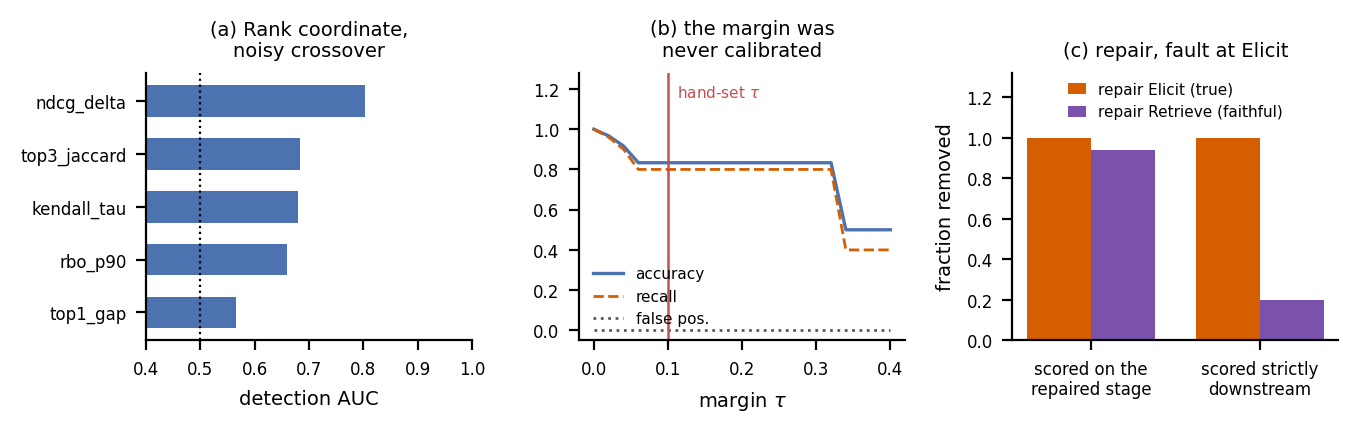

In [13]:
from IPython.display import Image
Image(filename="paper/figures/fig_scaff_robustness.png")

### Claims that survive, in the form they should appear

1. **Localization**: 100% on 120 scenarios, 95% Wilson CI [0.969, 1.000]; 0.958–1.000 across five
   seeds (mean 0.992). Not a bare "100%".
2. **The crossover's $\epsilon$ must be shared across cells.** Independent draws drop localization
   from 100% to 16.7–82.5% depending on the coordinate. This is a requirement on any real-data
   setting, not an implementation note.
3. **Rank's coordinate**: `ndcg_delta` where an oracle exists (AUC 0.804 in the noisy regime),
   `rbo_p90` where none does. `top1_gap` is unusable (AUC 0.566).
4. **The margin is calibrated**, not chosen: $\tau^\star = 0$ from the controls' own noise. The
   hand-set 0.10 costs 16.7 points of accuracy on every seed by silently assuming a coordinate scale.
5. **Repair** is scored strictly downstream: diagonal 1.0, largest off-diagonal 0.20. Under the
   original scoring the entire Rank column reads 1.0 and the test is vacuous. Repair removability is
   **identified only for Elicit and Retrieve faults** in a single-turn pipeline.
6. **Endpoint masking** splits in two: 5.0% masked among pairs that could move, and 40 pairs blind
   by construction with a maximum endpoint distance of exactly 0.0. A second turn removes the
   blindness.

### What this hands to the real-data work

The two selection criteria that follow directly, and that the benchmark/dataset audit should treat
as binding: the setting must expose **seed-controllable stage sampling** (or accept the noisy-regime
penalty), and it needs **an oracle at Rank** for `ndcg_delta` to be available — otherwise the audit
runs on `rbo_p90` with a materially weaker detector.